First, we need to import any libraries we need. We need pandas, numpy, and sklearn specifically for our data analysis. We also import any machine learning models we will use and the ways we can evaluate those models through the R2 Score and mean squared error.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

Mounted at /content/drive


Next, we need to read in the dataset which can be stored in Google Drive. To visualize some of the dataset, we printed out the first five rows of the dataset. Our dataset is linked here:(https://docs.google.com/spreadsheets/d/1cky0Iul9ICBIbgtauTLR8NXhQLnIGkob5ygEiWA2Xxs/edit?gid=1187008676#gid=1187008676)

The link to our notebook for how we cleaned our data: (https://drive.google.com/file/d/1GnOp0zv9WivFcmmg6AmTIjBDZM4tBWXY/view?usp=sharing)

In [2]:
#data = pd.read_csv("drive/My Drive/cleaned_tyler_df(kagglekworb.csv")
data = pd.read_csv("drive/My Drive/UCLA/Student Organizations/NSDC (National Student Data Corps at UCLA)/FallQ 2024 Project/TylerTheCreatorDF - cleaned_tyler_df(kagglekworb.csv")
data.head()

,artist_name,track_name,track_id,album_name,album_id,release_date,popularity,explicit,danceability,energy,...,duration,year,month,day_of_the_week,featured_artists_count,Streams,Daily,Years since release,Yearly Stream,Genres
0,"Tyler, The Creator",435,5xJeZ6tLPOXNIrrphEIuay,435,5wWkfNvfwMfQFbas9Gjggq,2018-06-08,62,True,0.539,0.804,...,93,2018,June,Friday,0,63383563,54748,6,1.056393e+07,Hip-Hop
1,"Tyler, The Creator",BEST INTEREST,3jHdKaLCkuNEkWcLVmQPCX,BEST INTEREST,5iUwaD3wFVwfaAfs9Z0eCh,2020-01-25,83,True,0.596,0.575,...,127,2020,January,Saturday,0,632344203,1000950,4,1.580861e+08,Hip-Hop/R&B
2,"Tyler, The Creator",WUSYANAME (feat. Youngboy Never Broke Again & ...,5B0kgjHULYJhAQkK5XsMoC,CALL ME IF YOU GET LOST,45ba6QAtNrdv6Ke4MFOKk9,2021-06-25,74,True,0.493,0.653,...,121,2021,June,Friday,2,368029332,266686,3,1.226764e+08,Hip-Hop/R&B
3,"Tyler, The Creator",SWEET / I THOUGHT YOU WANTED TO DANCE (feat. B...,3EG9FJ0ToLfgnc1IG2Z1wz,CALL ME IF YOU GET LOST,45ba6QAtNrdv6Ke4MFOKk9,2021-06-25,74,True,0.468,0.652,...,588,2021,June,Friday,2,304393352,296312,3,1.014645e+08,R&B/Soul
4,"Tyler, The Creator",SIR BAUDELAIRE (feat. DJ Drama),4ydmav4vl7hebadtfZtMrg,CALL ME IF YOU GET LOST,45ba6QAtNrdv6Ke4MFOKk9,2021-06-25,63,True,0.467,0.635,...,88,2021,June,Friday,1,90255792,82276,3,3.008526e+07,Hip-Hop


We display summary statistics for each feature in the dataset to see more about what type of data we are working with

In [ ]:
data.describe()

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration,year,featured_artists_count,Streams,Daily,Years since release,Yearly Stream
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,1.010000e+02,1.010000e+02,101.000000,1.010000e+02
mean,59.485149,0.549277,0.635901,-7.868406,0.236791,0.202708,0.048513,0.319295,0.446594,109.230406,3.930693,219.059406,2016.504950,0.732673,1.379826e+08,1.310600e+05,7.495050,2.893772e+07
std,10.536236,0.132921,0.143730,2.424160,0.151889,0.219273,0.177034,0.223709,0.192871,32.593925,0.430289,98.817997,3.933507,1.121527,2.450551e+08,3.185572e+05,3.933507,4.601316e+07
min,40.000000,0.216000,0.271000,-14.841000,0.027500,0.000063,0.000000,0.047600,0.064800,40.319000,1.000000,36.000000,2011.000000,0.000000,5.966566e+06,2.949000e+03,1.000000,5.336855e+05
25%,52.000000,0.458000,0.539000,-9.473000,0.095900,0.030200,0.000000,0.140000,0.297000,80.355000,4.000000,161.000000,2013.000000,0.000000,2.654807e+07,1.654600e+04,4.000000,2.632821e+06
50%,60.000000,0.547000,0.634000,-7.869000,0.241000,0.121000,0.000007,0.243000,0.455000,97.672000,4.000000,206.000000,2017.000000,0.000000,5.646988e+07,4.121700e+04,7.000000,1.395671e+07
75%,66.000000,0.638000,0.744000,-6.290000,0.355000,0.329000,0.000930,0.478000,0.584000,137.131000,4.000000,248.000000,2020.000000,1.000000,1.488889e+08,9.665000e+04,11.000000,3.067862e+07
max,89.000000,0.827000,0.932000,-2.389000,0.828000,0.959000,0.947000,0.890000,0.880000,187.308000,5.000000,588.000000,2023.000000,7.000000,1.935908e+09,2.720762e+06,13.000000,2.765583e+08


We created some new features of our own that we believe will help our model. The features are created using combinations of features from our original features.

The added features are:
- 'dance_factor'
- 'live_concert_energy'
- 'production_complexity'
- 'human_touch_factor'
- 'feel_good_index'

In [ ]:
data['dance_factor'] = (
        (data['valence'] * data['tempo'] * data['instrumentalness']) /
        (data['speechiness'])
        )

data['live_concert_energy'] = (
        data['liveness'] *
        data['acousticness'] *
        (1 / (data['speechiness']))
    )

data['production_complexity'] = (
        data['instrumentalness'] +
        (1 - data['acousticness']) +
        (data['time_signature'] / 4)
    )

data['human_touch_factor'] = (
        (1 - data['instrumentalness']) *
        (1 - data['speechiness']) *
        data['acousticness']
    )

data['feel_good_index'] = (
        (data['valence'] * data['tempo'] * data['duration'])
    )

We then apply principal component analysis, or PCA, which is a statistical method that reduces the dimensionality of a dataset by transforming it into a smaller set of variables called principal components, or PCs. It works by simplifying a large dataset into a smaller set while keeping the significant patterns and trends. This can help reduce model complexity, minimize overfitting and multicollinearity.

In [ ]:
pca_features = ['loudness', 'acousticness', 'liveness', 'danceability']
X_pca_input = data[pca_features]
X_pca_scaled = (X_pca_input - X_pca_input.mean()) / X_pca_input.std()
pca = PCA()
X_pca = pca.fit_transform(X_pca_scaled)
pca_component_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_component_names)
data = pd.concat([data.reset_index(drop=True), pca_df], axis=1)

We create additional features here based on our PCA features.

The features we create are:
- 'LoudToAcoustic'
- 'LivenessTimesDance'

In [ ]:
data['LoudToAcoustic'] = data['loudness'] * data['acousticness']
data['LivenessTimesDance'] = data['liveness'] * data['danceability']

This helps scale our target feature.

In [ ]:
target = 'Yearly Stream (log)'
data[target] = np.log1p(data['Yearly Stream'])
y = data[target]

Drop our redundant or unused features here. Having more features is not always a good thing since too many features can cause the model to be overfitted which will decrease it's accuracy.

In [ ]:
drop_columns = ['Yearly Stream', target] + pca_features
X = data.drop(columns=drop_columns, errors='ignore')

This encodes each of our categorical features so that we can analyze them in an numerical context.

In [ ]:
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

This is our mutual information analysis. Mutual information measures how much one random variable tells us about another random variable when sampled simultaneously. The closer to 0 an MI score is, the more the quantities are indepedent, meaning that the variables can't tell you anything about each other.

In [ ]:
mi_scores = mutual_info_regression(X, y)
mi_scores_series = pd.Series(mi_scores, name="MI Scores", index=X.columns).sort_values(ascending=False)
mi_scores_df = mi_scores_series.sort_values(ascending=False).reset_index()
mi_scores_df.columns = ['Feature', 'MI Score']
print(mi_scores_df)

                   Feature      MI Score
0               popularity  9.255451e-01
1                  Streams  8.660470e-01
2                    Daily  6.457618e-01
3                 track_id  5.865079e-01
4               track_name  5.857453e-01
5             release_date  5.586995e-01
6      Years since release  5.469238e-01
7               album_name  5.404455e-01
8                 album_id  5.292264e-01
9                     year  5.166166e-01
10                   month  4.514890e-01
11         day_of_the_week  3.586963e-01
12                     PC1  1.868024e-01
13     live_concert_energy  1.557565e-01
14                  Genres  1.440355e-01
15                 valence  1.012197e-01
16      human_touch_factor  9.884470e-02
17                    type  7.743837e-02
18                     PC2  6.428114e-02
19                     key  6.278565e-02
20          LoudToAcoustic  4.058223e-02
21        instrumentalness  2.403121e-02
22                explicit  1.663852e-02
23              

Show information for what our DataFrame contains.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 43 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   artist_name             101 non-null    object 
 1   track_name              101 non-null    object 
 2   track_id                101 non-null    object 
 3   album_name              101 non-null    object 
 4   album_id                101 non-null    object 
 5   release_date            101 non-null    object 
 6   popularity              101 non-null    int64  
 7   explicit                101 non-null    bool   
 8   danceability            101 non-null    float64
 9   energy                  101 non-null    float64
 10  key                     101 non-null    object 
 11  loudness                101 non-null    float64
 12  mode                    101 non-null    object 
 13  speechiness             101 non-null    float64
 14  acousticness            101 non-null    fl

Now split and train the testing and training data. We use 80% of our data to train our models.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

Now we train our models. We decided to train Regressor models since our target feature, 'Yearly Stream', is a numerical value. Regressor models are more commonly used when the value we are trying to predict is numerical. Classifier models are more commonly used when the value we are trying to predict is a class. Since we don't have any classes, Classifier Machine Learning models wouldn't work and would throw an error. The features we are using to predict our predicted values are also all numerical values. Knowing all of this, we decided that Regressor models are the best choice with our data.

The Regressor models we chose to train were:
- Gradient Boosting Regressor
- Linear Regression
- Random Forest Regressor
- Decision Trees Regressor

To determine the accuracy of the Regressor models, we look at the R squared value and the mean squared value.

The R squared value determines how well a regression model fits our data. The closer the R squared value is to 1, the better.

The mean squared value measures the average of the squares of the errors, which determines how much the actual data points differ from our regression line. The closer our mean squared value is to 0, the better.

From our preliminary tests, the best performing models were our Gradient Boosting Regressor, Linear Regression, and Random Forest Regressor models.

In [ ]:
regressor_models = {
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state = 42),
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state = 42),
    "Decision Trees Regressor": DecisionTreeRegressor(random_state = 42)
}
regressor_model_performance = {}
for regressor_model_name, regressor_model in regressor_models.items():
  regressor_model.fit(X_train, y_train)
  y_pred = regressor_model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  regressor_model_performance[regressor_model_name] = {"MSE": mse, "R2 Score": r2}
  print(f"{regressor_model_name} Performance:")
  print(f"  Mean Squared Error (MSE): {mse}")
  print(f"  R² Score: {r2}")
  print("="*40)

Gradient Boosting Regressor Performance:
  Mean Squared Error (MSE): 0.14601922514417853
  R² Score: 0.9189618327451703
Linear Regression Performance:
  Mean Squared Error (MSE): 0.20527437152070746
  R² Score: 0.8860762421112713
Random Forest Regressor Performance:
  Mean Squared Error (MSE): 0.21722015099798883
  R² Score: 0.8794465392463686
Decision Trees Regressor Performance:
  Mean Squared Error (MSE): 0.3294215431348407
  R² Score: 0.817176689689004


After training and evaluating the performance of our model, we find that we have a pretty good model with an R Squared score of about 0.9191

But we can still find ways to improve our model. One way to do this is through hyperparameter tuning.

Hyperparameter tuning works by trying to find the best hyperparameters for a learning algorithm. Hyperparameters are model parameters that controls the learning process and isn't estimated from training data. Hyperparameter tuning will optimize the model's performance by finding the best hyperparameters.

In [ ]:
# Parameter grids for hyperparameter tuning
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Random Forest Regressor Tuning
rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)
best_rf_params = rf_grid_search.best_params_
best_rf_score = rf_grid_search.best_score_

# Gradient Boosting Regressor Tuning
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)
gb_grid_search.fit(X_train, y_train)
best_gb_params = gb_grid_search.best_params_
best_gb_score = gb_grid_search.best_score_

# Display results
print("Best Parameters and Scores:")
print(f"Random Forest Best Params: {best_rf_params}, Best R² Score: {best_rf_score}")
print(f"Gradient Boosting Best Params: {best_gb_params}, Best R² Score: {best_gb_score}")

Fitting 3 folds for each of 162 candidates, totalling 486 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
243 fits failed out of a total of 486.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
116 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/util

Fitting 3 folds for each of 486 candidates, totalling 1458 fits
Best Parameters and Scores:
Random Forest Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}, Best R² Score: 0.8903328318100314
Gradient Boosting Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}, Best R² Score: 0.9363634607604986


After conducting hyperparameter tuning and finding the optimal parameters, we find that our models did show improvement:

- Our Gradient Boosting model R Squared Score went up to about 0.9364 from about 0.9191

- Our Random Forest model R Squared Score went up to 0.8903 from about 0.8795


To better show our model performance, we can visualize our data. We create two bar graphs below to visualize the Mean Squared Error and the R2 Score of our Machine Learning models.

From our data visualization, it is pretty apparent that our Gradient Boosting Regressor model is our best performing model. It has the lowest Mean Squared Error and the highest R Squared Value.

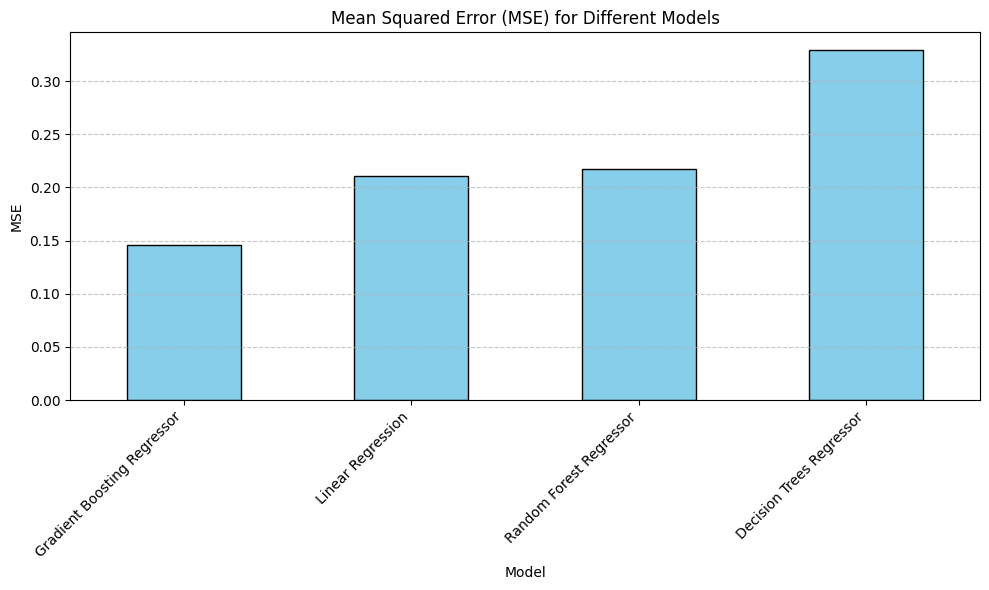

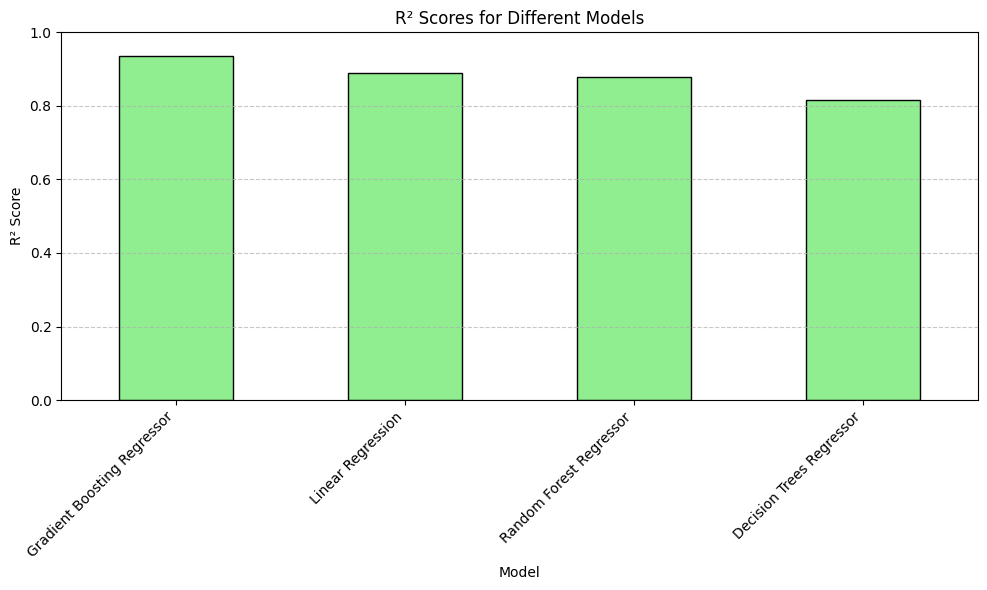

In [ ]:
regressor_model_performance = {
    "Gradient Boosting Regressor": {"MSE": 0.14585457786585826, "R2 Score": 0.9363634607604986},
    "Linear Regression": {"MSE": 0.21107198862854398, "R2 Score": 0.8903328318100314},
    "Random Forest Regressor": {"MSE": 0.21722015099798883, "R2 Score": 0.8794465392463686},
    "Decision Trees Regressor": {"MSE": 0.3294215431348407, "R2 Score": 0.817176689689004}
}

# Convert dictionary to DataFrame for visualization
performance_df = pd.DataFrame(regressor_model_performance).T

# Plot MSE values
plt.figure(figsize=(10, 6))
performance_df['MSE'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Mean Squared Error (MSE) for Different Models")
plt.xlabel("Model")
plt.ylabel("MSE")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot R² values
plt.figure(figsize=(10, 6))
performance_df['R2 Score'].plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("R² Scores for Different Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)  # Limit R² range to [0, 1]
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Some further data visualization we can perform is to visualize the feature importance for our Gradient Boosting model. Feature importance shows how important each feature is to the performance of our Machine Learning model.

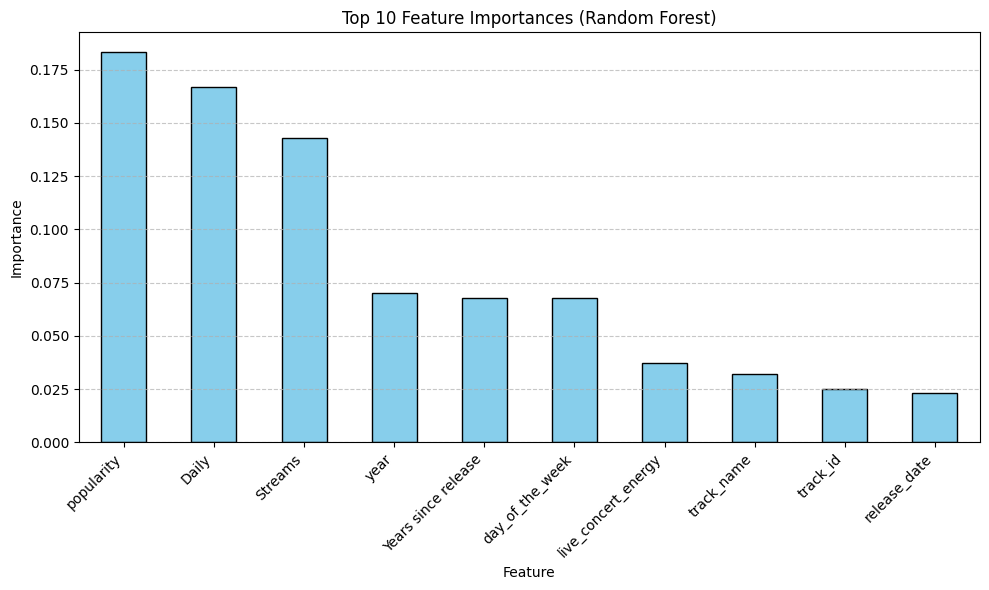

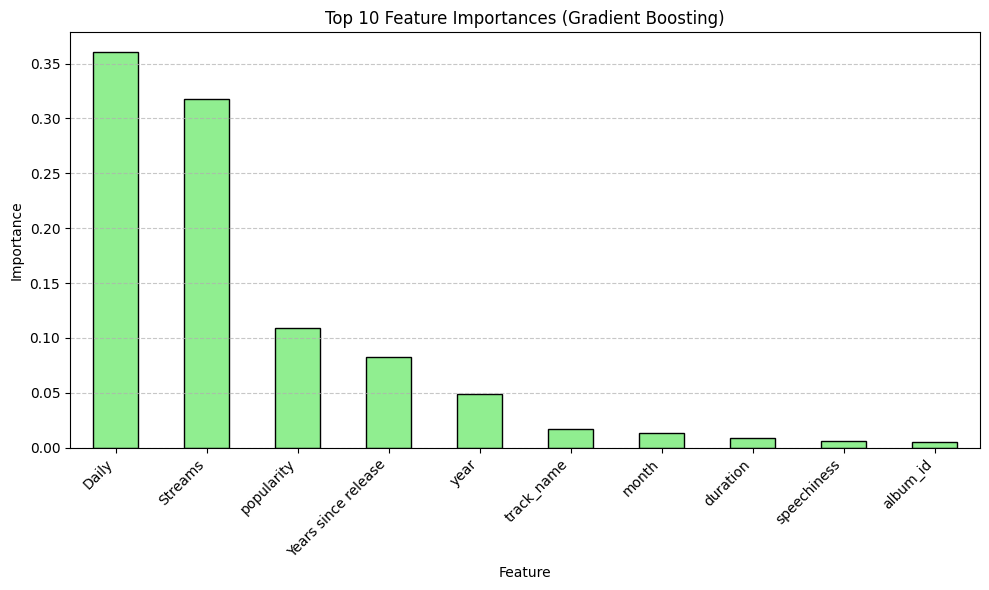

In [ ]:
# Extract feature importance from fitted Random Forest and Gradient Boosting models
rf_feature_importance = pd.Series(
    rf_grid_search.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

gb_feature_importance = pd.Series(
    gb_grid_search.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Visualize feature importance for Random Forest
plt.figure(figsize=(10, 6))
rf_feature_importance.head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize feature importance for Gradient Boosting
plt.figure(figsize=(10, 6))
gb_feature_importance.head(10).plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()